# Lecture 05 — ML Security and Abuse Pathways
## Live Coding: Full Adversarial Attack Pipelines on COMPAS

**Instructor:** Dr. Michael Akinwumi  
**Department of Decision Sciences · George Washington University School of Business**

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [1]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [14]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


# Homework 5:

## Part 1: PGD Evasion Audit

In [3]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records_lr = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records_lr.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

lr_df_pgd = pd.DataFrame(pgd_records_lr)
print(lr_df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


In [25]:
# ── GBT model: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular_scorebased(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40, h=1e-3):
    X_adv = X_scaled.copy()
    n, d  = X_adv.shape

    for step in range(n_iter):
        grads = np.zeros_like(X_adv)
        for j in range(d):
            X_plus  = X_adv.copy()
            X_minus = X_adv.copy()
            X_plus[:, j]  += h
            X_minus[:, j] -= h
            p_plus  = model.predict_proba(X_plus)[:, 1]
            p_minus = model.predict_proba(X_minus)[:, 1]
            grads[:, j] = (p_plus - p_minus) / (2 * h)

        X_adv = X_adv + alpha * np.sign(grads)
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── GBT baseline FPR (needed for delta calculation) ───────────────────────────
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)
fpr_gbt_base   = fpr_by_group(y_te, pred_gbt_clean, r_te)
BASELINE_AA_GBT = fpr_gbt_base.get('African-American')
BASELINE_CA_GBT = fpr_gbt_base.get('Caucasian')

# ── Sweep epsilon ──────────────────────────────────────────────────────────────
epsilons        = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records_gbt = []

for eps in epsilons:
    X_adv = Xs_te if eps == 0.0 else pgd_tabular_scorebased(
        gbt, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (gbt.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian', np.nan)

    pgd_records_gbt.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

gbt_df_pgd = pd.DataFrame(pgd_records_gbt)
print(gbt_df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.317   0.178 1.782     0.036     0.035
    0.25   0.317   0.178 1.782     0.036     0.035
    0.50   0.317   0.178 1.782     0.036     0.035
    0.75   0.317   0.178 1.782     0.036     0.035
    1.00   0.317   0.178 1.782     0.036     0.035
    1.50   0.317   0.178 1.782     0.036     0.035
    2.00   0.317   0.178 1.782     0.036     0.035


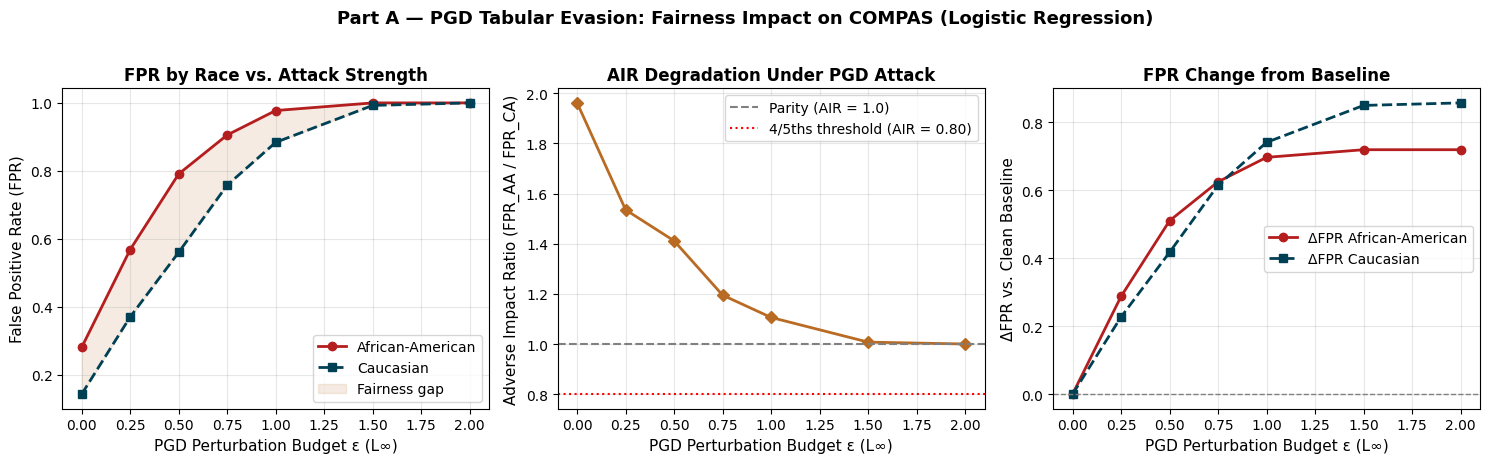

AIR does not fall below 0.80 within the tested epsilon range.


In [27]:
# ──  Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(lr_df_pgd['epsilon'], lr_df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(lr_df_pgd['epsilon'], lr_df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(lr_df_pgd['epsilon'], lr_df_pgd['FPR_AA'], lr_df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(lr_df_pgd['epsilon'], lr_df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(lr_df_pgd['epsilon'], lr_df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(lr_df_pgd['epsilon'], lr_df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = lr_df_pgd[lr_df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

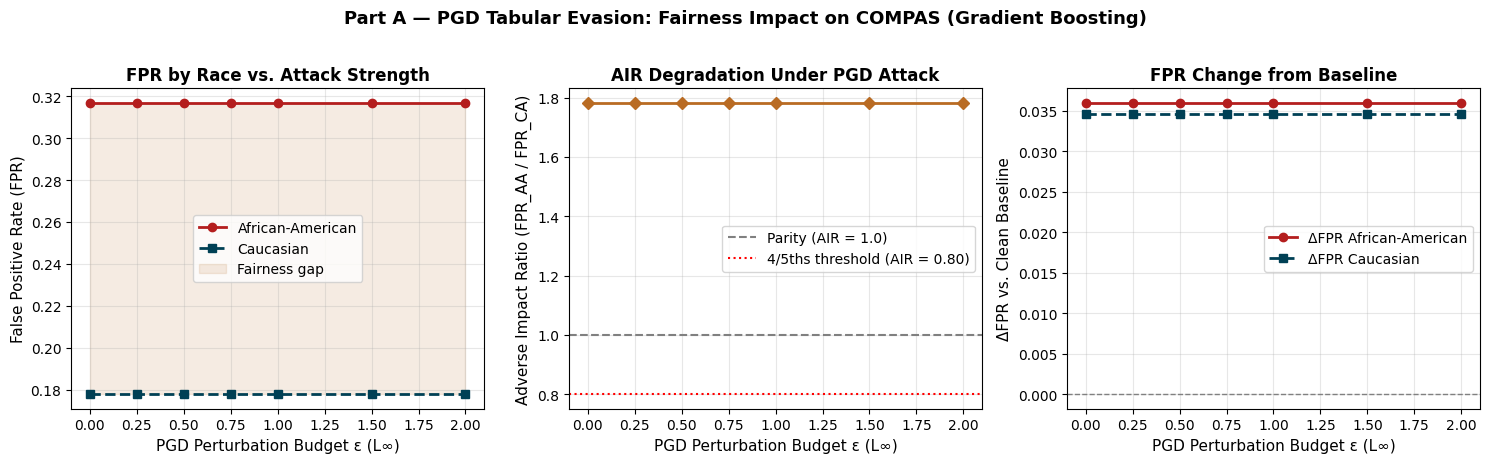

AIR does not fall below 0.80 within the tested epsilon range.


In [26]:
# ── GBT: Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(gbt_df_pgd['epsilon'], gbt_df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(gbt_df_pgd['epsilon'], gbt_df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(gbt_df_pgd['epsilon'], gbt_df_pgd['FPR_AA'], gbt_df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(gbt_df_pgd['epsilon'], gbt_df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(gbt_df_pgd['epsilon'], gbt_df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(gbt_df_pgd['epsilon'], gbt_df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Gradient Boosting)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = gbt_df_pgd[gbt_df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

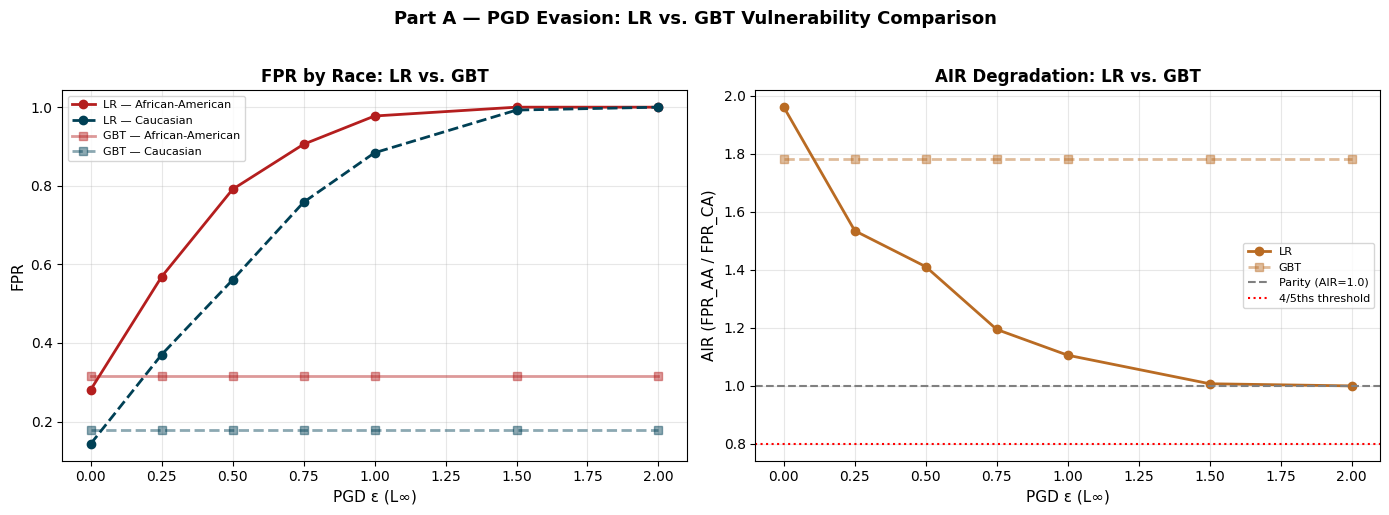

AIR crossover summary (ε at which AIR < 0.80):
  LR: AIR does not fall below 0.80 in tested range.
  GBT: AIR does not fall below 0.80 in tested range.


In [32]:
# ── Cell 4b: LR vs GBT PGD Comparison Plot ────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: FPR by race, both models ─────────────────────────────────────────
ax = axes[0]
ax.plot(lr_df_pgd['epsilon'],  lr_df_pgd['FPR_AA'],
        'o-',  color='#B41E1E', lw=2, label='LR — African-American')
ax.plot(lr_df_pgd['epsilon'],  lr_df_pgd['FPR_CA'],
        'o--', color='#004055', lw=2, label='LR — Caucasian')
ax.plot(gbt_df_pgd['epsilon'], gbt_df_pgd['FPR_AA'],
        's-',  color='#B41E1E', lw=2, alpha=0.45, label='GBT — African-American')
ax.plot(gbt_df_pgd['epsilon'], gbt_df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, alpha=0.45, label='GBT — Caucasian')
ax.set_xlabel('PGD ε (L∞)', fontsize=11)
ax.set_ylabel('FPR', fontsize=11)
ax.set_title('FPR by Race: LR vs. GBT', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 2: AIR, both models ─────────────────────────────────────────────────
ax = axes[1]
ax.plot(lr_df_pgd['epsilon'],  lr_df_pgd['AIR'],
        'o-',  color='#B96B23', lw=2, label='LR')
ax.plot(gbt_df_pgd['epsilon'], gbt_df_pgd['AIR'],
        's--', color='#B96B23', lw=2, alpha=0.45, label='GBT')
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR=1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold')
ax.set_xlabel('PGD ε (L∞)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation: LR vs. GBT', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Part A — PGD Evasion: LR vs. GBT Vulnerability Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── AIR crossover comparison ───────────────────────────────────────────────────
print("AIR crossover summary (ε at which AIR < 0.80):")
for name, df_p in [('LR', lr_df_pgd), ('GBT', gbt_df_pgd)]:
    cross = df_p[df_p['AIR'] < 0.80]
    if len(cross):
        print(f"  {name}: AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
    else:
        print(f"  {name}: AIR does not fall below 0.80 in tested range.")

## Part 2: Poisoning Loop with Fairness Monitoring

In [8]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Sweep poison rates ────────────────────────────────────────────────────────
poison_rates   = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate
    )

    # Retrain LR on poisoned data (same features, same scaler)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)

    poison_records.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped,
        'AUC'         : auc_p,
        'delta_AUC'   : auc_p - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison = pd.DataFrame(poison_records)
print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

# ── Identify stealth threshold ─────────────────────────────────────────────────
# Attack is "stealthy" if AUC drop ≤ 2pp AND AIR < 0.80
stealth = df_poison[(df_poison['AIR'] < 0.80) & (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print(f"\n★ Stealth threshold: poison_rate = {r['poison_rate']:.0%}")
    print(f"  Flipped labels: {int(r['n_flipped'])}")
    print(f"  AUC: {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"  AIR: {r['AIR']:.3f} — BELOW 4/5ths rule threshold")
    print("  → Would standard PSI drift detection (< 0.10) flag this?")
else:
    print("\nNo stealth threshold found in tested range.")

Poisoning sweep results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

No stealth threshold found in tested range.


### Extend the label-flip poisoning loop to target Caucasian defendants instead of African-American.

In [33]:
# ── Poisoning Loop: Caucasian Target ──────────────

# Sweep both target races
poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
records_ca = []

for rate in poison_rates:
    y_tr_poisoned_ca, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate,
        target_race='Caucasian', seed=0
    )
    lr_p_ca = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned_ca)
    pred_p  = (lr_p_ca.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p   = roc_auc_score(y_te, lr_p_ca.predict_proba(Xs_te)[:,1])
    fpr_p   = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)
    records_ca.append({
        'poison_rate': rate,
        'AUC':        auc_p,
        'delta_AUC':  auc_p - baseline_auc,
        'FPR_AA':     aa,
        'FPR_CA':     ca,
        'AIR':        air(ca, aa),
    })

df_poison_ca = pd.DataFrame(records_ca)
print("Caucasian-targeted poisoning results:")
print(df_poison_ca.round(3).to_string(index=False))

Caucasian-targeted poisoning results:
 poison_rate   AUC  delta_AUC  FPR_AA  FPR_CA   AIR
        0.00 0.735      0.000   0.281   0.143 1.961
        0.02 0.734     -0.001   0.274   0.141 1.948
        0.05 0.734     -0.000   0.267   0.131 2.043
        0.08 0.734     -0.000   0.245   0.126 1.945
        0.10 0.735      0.001   0.243   0.123 1.966
        0.15 0.733     -0.002   0.231   0.121 1.913
        0.20 0.733     -0.001   0.209   0.111 1.881
        0.25 0.733     -0.001   0.191   0.104 1.842
        0.30 0.732     -0.003   0.182   0.094 1.940


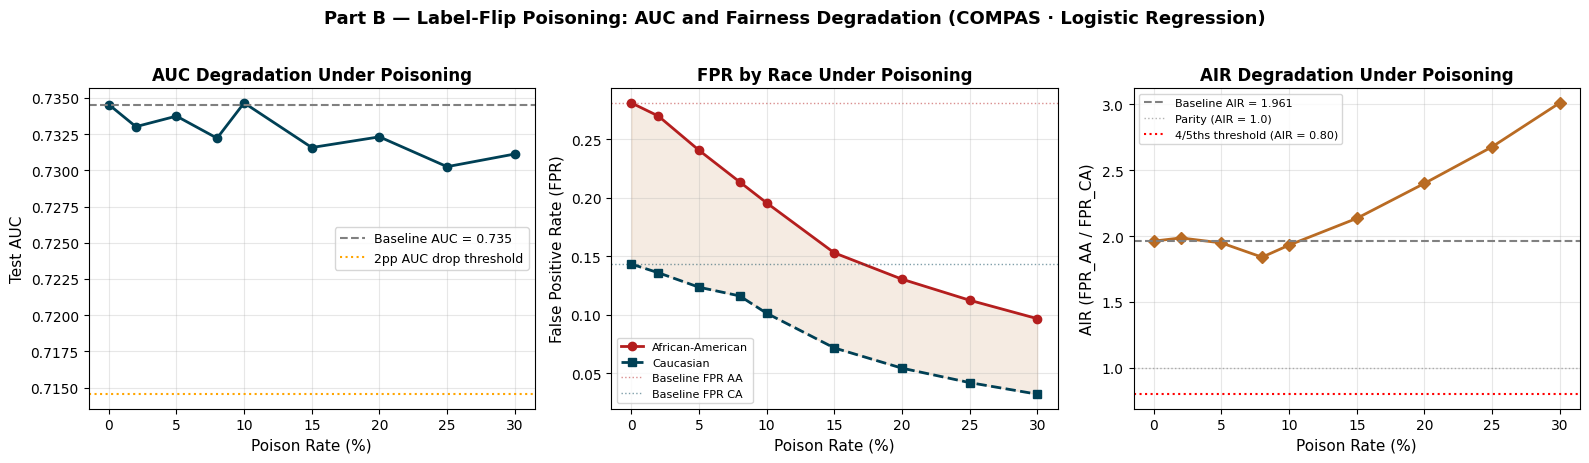

In [9]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### (a) Plot AUC and AIR degradation curves for both target-race variants on the same axes.

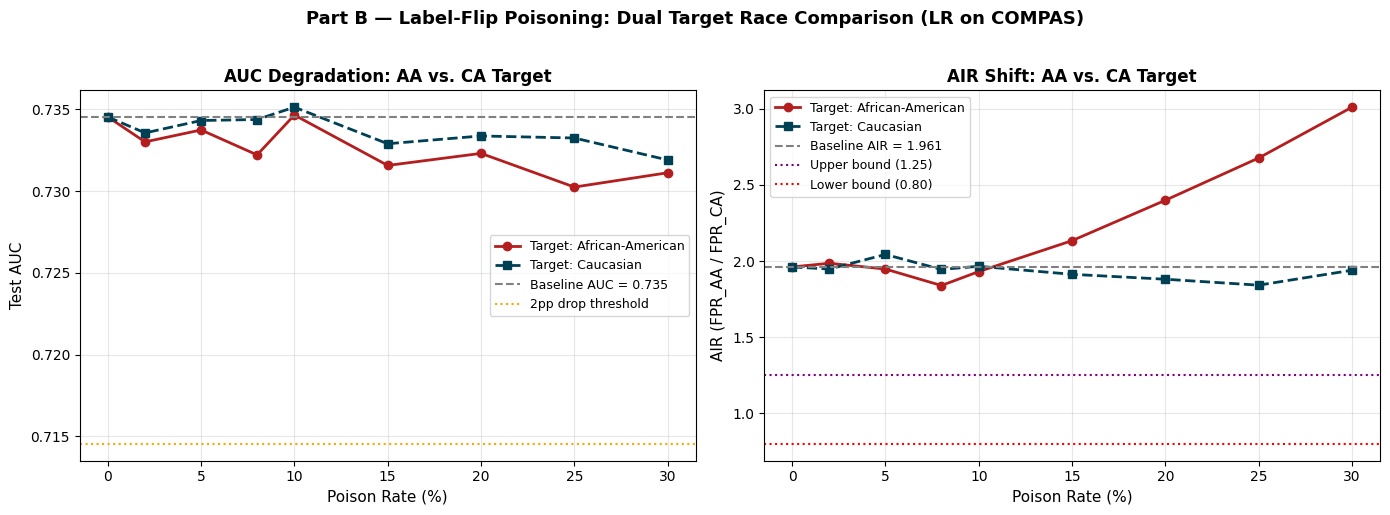

In [40]:
# ── Plot AUC and AIR degradation curves for both target-race variants on the same axes. ──────────────

x_pct = df_poison['poison_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: AUC — both targets ───────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'],
        'o-', color='#B41E1E', lw=2, label='Target: African-American')
ax.plot(x_pct, df_poison_ca['AUC'],
        's--', color='#004055', lw=2, label='Target: Caucasian')
ax.axhline(baseline_auc,        color='gray',   ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02, color='orange', ls=':',  lw=1.5,
           label='2pp drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation: AA vs. CA Target', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: AIR — both targets ───────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['AIR'],
        'o-', color='#B41E1E', lw=2, label='Target: African-American')
ax.plot(x_pct, df_poison_ca['AIR'],
        's--', color='#004055', lw=2, label='Target: Caucasian')
ax.axhline(BASELINE_AIR, color='gray',   ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.25, color='purple', ls=':', lw=1.5, label='Upper bound (1.25)')
ax.axhline(0.80, color='red',    ls=':', lw=1.5, label='Lower bound (0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Shift: AA vs. CA Target', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: Dual Target Race Comparison (LR on COMPAS)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### (b) Identify the “stealth zone”: the range of poison rates where AUC declines by ≤ 2 pp while AIR moves outside [0.80, 1.25].

In [57]:
# ── Stealth zone analysis for both variants ────────────────────────────────────
for label, df_p in [('African-American target', df_poison),
                     ('Caucasian target',        df_poison_ca)]:
    stealth = df_p[
        (df_p['delta_AUC'] >= -0.02) &
        ((df_p['AIR'] < 0.80) | (df_p['AIR'] > 1.25))
    ]
    if len(stealth):
        rates = stealth['poison_rate'].values
        print(f"Stealth zone [{label}]: poison rate {rates[0]:.0%}-{rates[-1]:.0%}")
    else:
        print(f"  No stealth zone found for {label}.")

Stealth zone [African-American target]: poison rate 0%-30%
Stealth zone [Caucasian target]: poison rate 0%-30%


### (c) Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect either attack?

In [56]:
# ──  PSI-based Drift Detection ────────────────────────────────────────

def compute_psi(expected, actual, buckets=10):
    """Population Stability Index between two distributions."""
    breakpoints = np.linspace(
        min(expected.min(), actual.min()),
        max(expected.max(), actual.max()),
        buckets + 1
    )
    exp_counts = np.histogram(expected, bins=breakpoints)[0] + 1e-6
    act_counts = np.histogram(actual,   bins=breakpoints)[0] + 1e-6
    exp_pct = exp_counts / exp_counts.sum()
    act_pct = act_counts / act_counts.sum()
    return np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))

PSI_THRESHOLD = 0.10
psi_records   = []

print("PSI Drift Detection across all poison rates")
print("=" * 65)

for target_race, label in [('African-American', 'AA-target'),
                             ('Caucasian',        'CA-target')]:
    for rate in poison_rates:
        y_p, _ = poison_label_flip(
            y_tr, r_tr, poison_rate=rate,
            target_race=target_race, seed=0
        )
        psi_label = compute_psi(y_tr.astype(float), y_p.astype(float))
        psi_records.append({
            'target'     : label,
            'poison_rate': rate,
            'label_PSI'  : psi_label,
            'flagged'    : psi_label > PSI_THRESHOLD,
        })

df_psi = pd.DataFrame(psi_records)
print(df_psi.round(4).to_string(index=False))

# ── First detection point for each target ─────────────────────────────────────
print("\nFirst poison rate where label PSI exceeds threshold (0.10):")
for label in ['AA-target', 'CA-target']:
    flagged = df_psi[(df_psi['target'] == label) & (df_psi['flagged'])]
    if len(flagged):
        r = flagged.iloc[0]
        print(f"  {label}: detected at poison rate = {r['poison_rate']:.0%}  (PSI = {r['label_PSI']:.4f})")
    else:
        print(f"  {label}: NOT detected at any tested poison rate")

print("\nNote: Feature PSI = 0 at all rates — label-flip does not alter X.")
print("A feature-only PSI monitor would never detect this attack.")

PSI Drift Detection across all poison rates
   target  poison_rate  label_PSI  flagged
AA-target         0.00     0.0000    False
AA-target         0.02     0.0001    False
AA-target         0.05     0.0007    False
AA-target         0.08     0.0018    False
AA-target         0.10     0.0029    False
AA-target         0.15     0.0065    False
AA-target         0.20     0.0116    False
AA-target         0.25     0.0181    False
AA-target         0.30     0.0263    False
CA-target         0.00     0.0000    False
CA-target         0.02     0.0000    False
CA-target         0.05     0.0002    False
CA-target         0.08     0.0005    False
CA-target         0.10     0.0007    False
CA-target         0.15     0.0016    False
CA-target         0.20     0.0029    False
CA-target         0.25     0.0046    False
CA-target         0.30     0.0066    False

First poison rate where label PSI exceeds threshold (0.10):
  AA-target: NOT detected at any tested poison rate
  CA-target: NOT detected 

## Part 3: Membership Inference Depth

In [10]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


In [42]:
# ──  Membership Inference on LR model ─────────────────────────────────

# Shadow models for LR
shadow_train_confs_lr = []
shadow_test_confs_lr  = []

print(f"Training {N_SHADOW} shadow models (LR)...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow_lr = LogisticRegression(max_iter=1000).fit(
        Xs_tr[tr_idx], y_tr[tr_idx]
    )
    shadow_train_confs_lr.append(
        shadow_lr.predict_proba(Xs_tr[tr_idx]).max(axis=1)
    )
    shadow_test_confs_lr.append(
        shadow_lr.predict_proba(Xs_tr[te_idx]).max(axis=1)
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

mi_X_lr = np.concatenate(
    shadow_train_confs_lr + shadow_test_confs_lr
).reshape(-1, 1)
mi_y_lr = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs_lr] +
    [np.zeros(len(c)) for c in shadow_test_confs_lr]
)
meta_clf_lr = DecisionTreeClassifier(max_depth=6).fit(mi_X_lr, mi_y_lr)

# Apply to LR target
conf_lr_train = lr.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_lr_test  = lr.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_lr = np.concatenate([
    meta_clf_lr.predict_proba(conf_lr_train)[:, 1],
    meta_clf_lr.predict_proba(conf_lr_test)[:, 1]
])
mi_labels_lr = np.concatenate([
    np.ones(len(Xs_tr)), np.zeros(len(Xs_te))
])
mi_auc_lr = roc_auc_score(mi_labels_lr, mi_scores_lr)

auc_train_lr = roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:, 1])
auc_test_lr  = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])
gen_gap_lr   = auc_train_lr - auc_test_lr

print(f"\nLR  Train AUC: {auc_train_lr:.3f} | Test AUC: {auc_test_lr:.3f} | Gen Gap: {gen_gap_lr:+.3f}")
print(f"LR  MI AUC  : {mi_auc_lr:.3f}")
print(f"GBT MI AUC  : {mi_auc:.3f}  (gen gap = {gen_gap:+.3f})")

Training 10 shadow models (LR)...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

LR  Train AUC: 0.727 | Test AUC: 0.735 | Gen Gap: -0.008
LR  MI AUC  : 0.497
GBT MI AUC  : 0.500  (gen gap = +0.080)


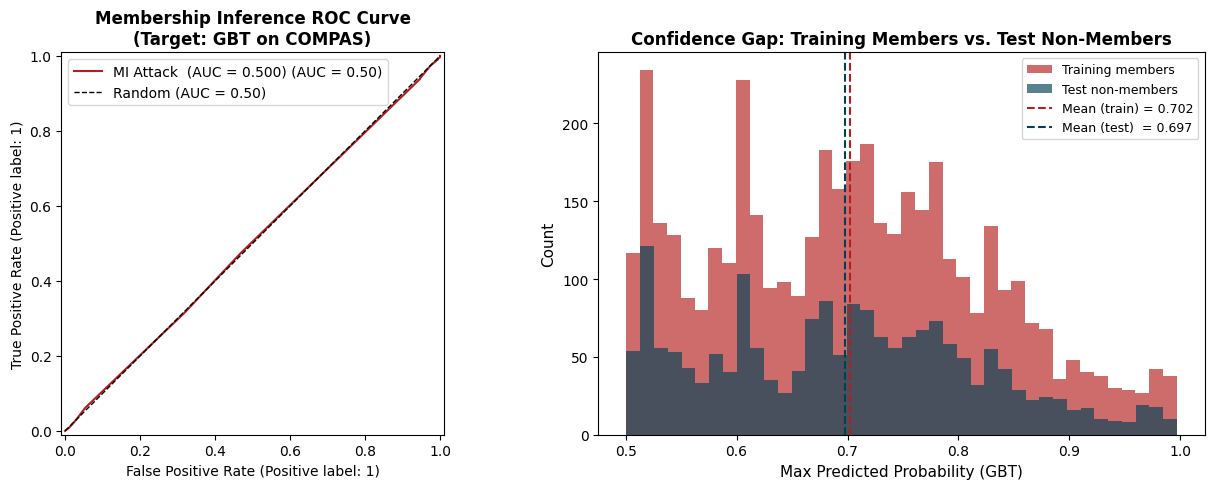

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [11]:
# ── Cell 8: Membership Inference — ROC Curve and Interpretation ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

### (a) Plot the confidence-gap histogram for each model side by side.

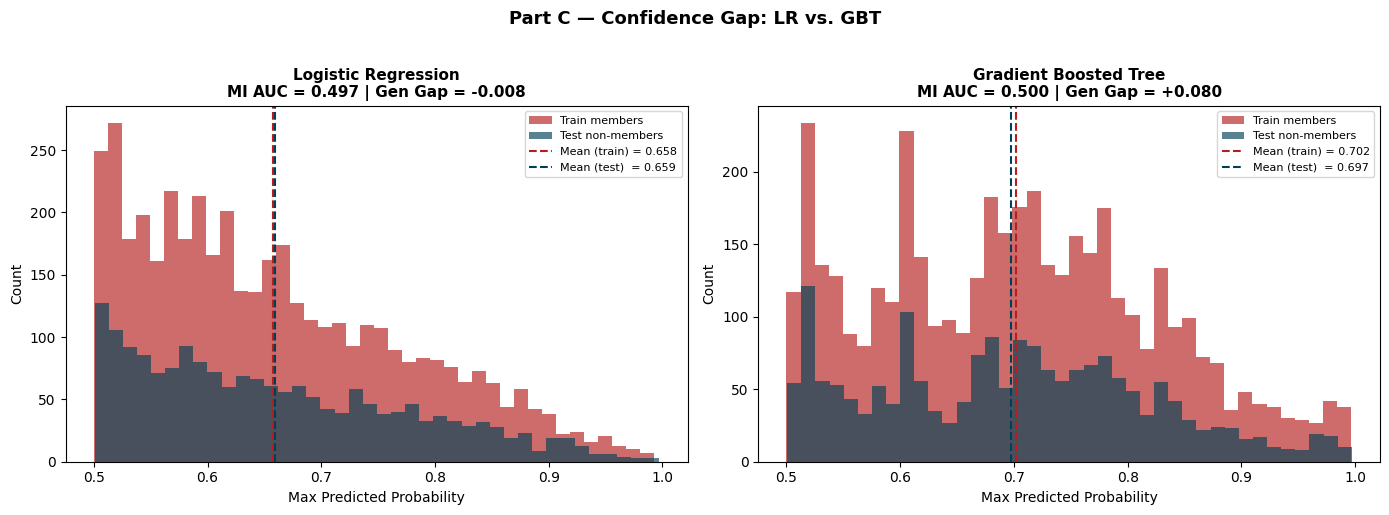

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, conf_train, conf_test, mi_auc_val, gap) in zip(axes, [
    ('Logistic Regression', conf_lr_train, conf_lr_test, mi_auc_lr, gen_gap_lr),
    ('Gradient Boosted Tree', conf_target_train, conf_target_test, mi_auc, gen_gap),
]):
    ax.hist(conf_train.ravel(), bins=40, alpha=0.65,
            color='#B41E1E', label='Train members')
    ax.hist(conf_test.ravel(),  bins=40, alpha=0.65,
            color='#004055', label='Test non-members')
    ax.axvline(conf_train.mean(), color='#B41E1E', ls='--', lw=1.5,
               label=f'Mean (train) = {conf_train.mean():.3f}')
    ax.axvline(conf_test.mean(),  color='#004055', ls='--', lw=1.5,
               label=f'Mean (test)  = {conf_test.mean():.3f}')
    ax.set_title(f'{name}\nMI AUC = {mi_auc_val:.3f} | Gen Gap = {gap:+.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Max Predicted Probability', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Part C — Confidence Gap: LR vs. GBT', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### (b) Test whether the generalization gap (train AUC - test AUC) predicts the MI AUC across the two models.

In [60]:
# ── Gen gap vs MI AUC summary ──────────────────────────────────────────────────
print("\nGeneralization Gap → MI AUC Relationship:")
print(f"  LR  : gen gap = {gen_gap_lr:+.3f}, MI AUC = {mi_auc_lr:.3f}")
print(f"  GBT : gen gap = {gen_gap:+.3f}, MI AUC = {mi_auc:.3f}")
print(f"\n  Theory predicts MI AUC ≈ 0.5 + gen_gap/2")
print(f"  LR  predicted: {0.5 + gen_gap_lr/2:.3f}")
print(f"  GBT predicted: {0.5 + gen_gap/2:.3f}")


Generalization Gap → MI AUC Relationship:
  LR  : gen gap = -0.008, MI AUC = 0.497
  GBT : gen gap = +0.080, MI AUC = 0.500

  Theory predicts MI AUC ≈ 0.5 + gen_gap/2
  LR  predicted: 0.496
  GBT predicted: 0.540


### (c) Add L2 regularization to the LR model (vary C ∈ {0.01, 0.1, 1.0, 10.0}), recompute MI AUC, and plot MI AUC vs. C.

Running L2 regularization sweep C ∈ {0.01, 0.1, 1.0, 10.0}...
  C= 0.01  TrainAUC=0.726  TestAUC=0.732  Gap=-0.006  MI_AUC=0.493  AIR=1.966
  C= 0.10  TrainAUC=0.727  TestAUC=0.734  Gap=-0.007  MI_AUC=0.495  AIR=1.946
  C= 1.00  TrainAUC=0.727  TestAUC=0.735  Gap=-0.008  MI_AUC=0.494  AIR=1.961
  C=10.00  TrainAUC=0.727  TestAUC=0.735  Gap=-0.008  MI_AUC=0.495  AIR=1.961


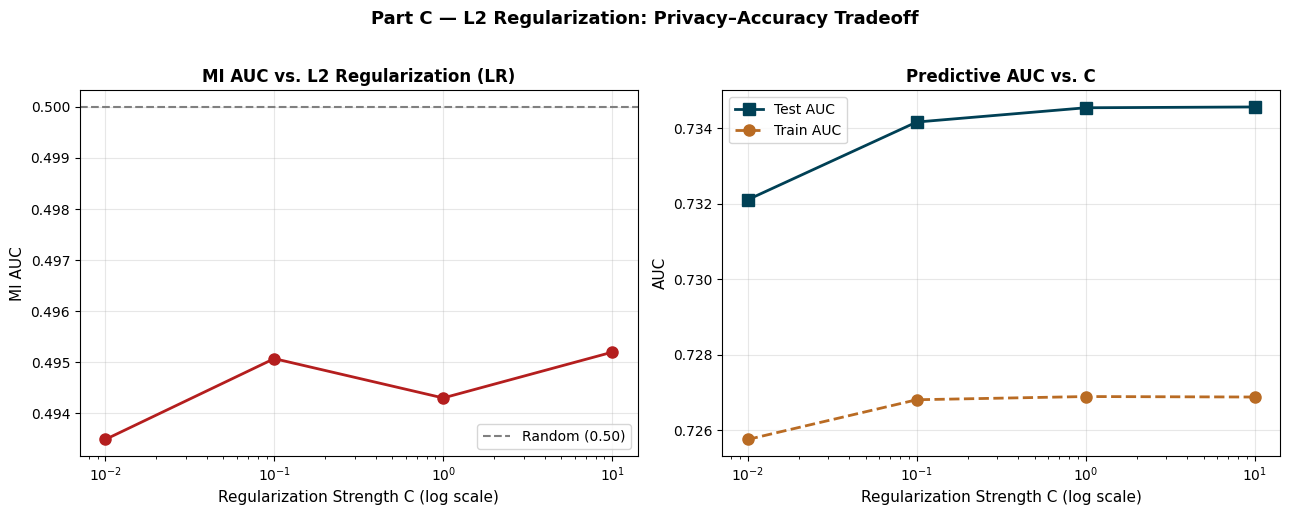


Practical Tradeoff:
    C  Test_AUC  Gen_Gap  MI_AUC
 0.01     0.732   -0.006   0.493
 0.10     0.734   -0.007   0.495
 1.00     0.735   -0.008   0.494
10.00     0.735   -0.008   0.495

  Lower C = stronger regularization = smaller gen gap = lower MI AUC
  But lower C also reduces model expressiveness → lower Test AUC


In [53]:
# ── L2 Regularization Sweep — MI AUC vs. C ──────────────────────────

C_VALUES = [0.01, 0.1, 1.0, 10.0]
reg_rows  = []

print("Running L2 regularization sweep C ∈ {0.01, 0.1, 1.0, 10.0}...")
for C in C_VALUES:
    lr_c = LogisticRegression(C=C, max_iter=1000, random_state=42).fit(Xs_tr, y_tr)

    # Generalization metrics
    auc_tr_c = roc_auc_score(y_tr, lr_c.predict_proba(Xs_tr)[:, 1])
    auc_te_c = roc_auc_score(y_te, lr_c.predict_proba(Xs_te)[:, 1])
    gap_c    = auc_tr_c - auc_te_c

    # MI attack (reuse existing meta_clf)
    conf_tr_c = lr_c.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_te_c = lr_c.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)
    mi_sc = np.concatenate([
        meta_clf.predict_proba(conf_tr_c)[:, 1],
        meta_clf.predict_proba(conf_te_c)[:, 1]
    ])
    mi_lab = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
    mi_c   = roc_auc_score(mi_lab, mi_sc)

    # AIR at C
    pred_c = (lr_c.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    fpr_c  = fpr_by_group(y_te, pred_c, r_te)
    aa_c   = fpr_c.get('African-American', np.nan)
    ca_c   = fpr_c.get('Caucasian', np.nan)
    air_c  = air(ca_c, aa_c)

    reg_rows.append({'C': C, 'Train_AUC': auc_tr_c, 'Test_AUC': auc_te_c,
                     'Gen_Gap': gap_c, 'MI_AUC': mi_c,
                     'FPR_AA': aa_c, 'FPR_CA': ca_c, 'AIR': air_c})
    print(f"  C={C:5.2f}  TrainAUC={auc_tr_c:.3f}  TestAUC={auc_te_c:.3f}  "
          f"Gap={gap_c:+.3f}  MI_AUC={mi_c:.3f}  AIR={air_c:.3f}")

df_reg = pd.DataFrame(reg_rows)

# ── Plot MI AUC vs C ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogx(df_reg['C'], df_reg['MI_AUC'],        # ← MI_AUC
            'o-', color='#B41E1E', lw=2, markersize=8)
ax.axhline(0.5, color='gray', ls='--', lw=1.5, label='Random (0.50)')
ax.set_xlabel('Regularization Strength C (log scale)', fontsize=11)
ax.set_ylabel('MI AUC', fontsize=11)
ax.set_title('MI AUC vs. L2 Regularization (LR)', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.semilogx(df_reg['C'], df_reg['Test_AUC'],       # ← Test_AUC
            's-', color='#004055', lw=2, markersize=8, label='Test AUC')
ax.semilogx(df_reg['C'], df_reg['Train_AUC'],      # ← Train_AUC
            'o--', color='#B96B23', lw=2, markersize=8, label='Train AUC')
ax.set_xlabel('Regularization Strength C (log scale)', fontsize=11)
ax.set_ylabel('AUC', fontsize=11)
ax.set_title('Predictive AUC vs. C', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Part C — L2 Regularization: Privacy–Accuracy Tradeoff',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nPractical Tradeoff:")
print(df_reg[['C', 'Test_AUC', 'Gen_Gap', 'MI_AUC']].round(3).to_string(index=False))  # ← 全换下划线
print("\n  Lower C = stronger regularization = smaller gen gap = lower MI AUC")
print("  But lower C also reduces model expressiveness → lower Test AUC")

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*